<a href="https://colab.research.google.com/github/starsyntaxx/30_days_of_Machine_Learning/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv
/kaggle/input/notebooks/aladejebidorcas/01-eda/__results__.html
/kaggle/input/notebooks/aladejebidorcas/01-eda/__notebook__.ipynb
/kaggle/input/notebooks/aladejebidorcas/01-eda/__output__.json
/kaggle/input/notebooks/aladejebidorcas/01-eda/custom.css
/kaggle/input/notebooks/aladejebidorcas/01-eda/.virtual_documents/__notebook_source__.ipynb


In [ ]:
train = pd.read_csv("/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv")
test = pd.read_csv("/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv"
)

In [ ]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [ ]:
print("TRAIN:", train.shape)
print("TEST:", test.shape)
print("SAMPLE:", sample_submission.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSample submission:")
display(sample_submission.head())

TRAIN: (6818, 13)
TEST: (1705, 12)
SAMPLE: (1705, 2)

Train columns:
['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'total_sales']

Test columns:
['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format']

Sample submission:


,id,total_sales
0,row_00009,2174.76
1,row_00015,2174.76
2,row_00019,2174.76
3,row_00020,2174.76
4,row_00023,2174.76


**EXPLORATORY ANALYSIS ON TRAIN DATASET**

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [ ]:
#check for missing values
train.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

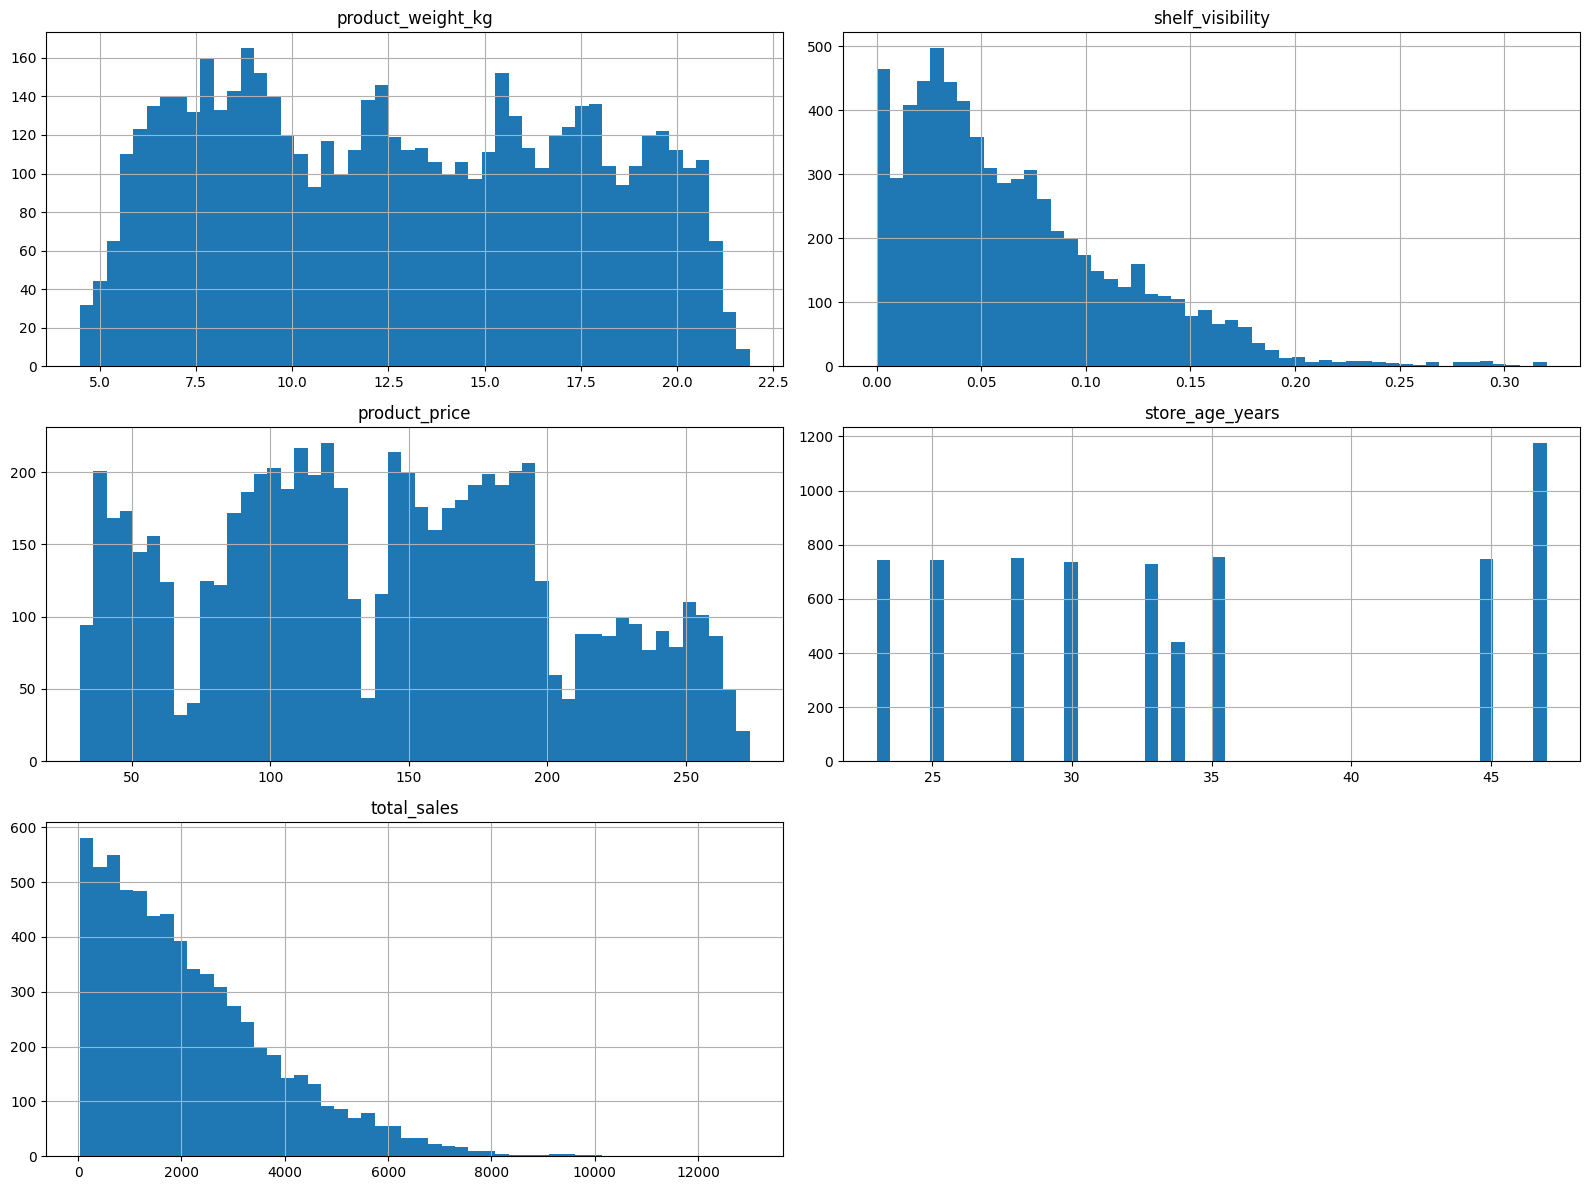

In [ ]:
# Automatically scales grid layout and sizes the window
train.hist(bins=50, figsize=(16, 12))
plt.tight_layout()
plt.show()

**SPLIT DATASET FOR TRAINING**

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Create quantile bins on total_sales to ensure both sets share the same sales distribution
strat_bins = pd.qcut(train['total_sales'], q=10, labels=False, duplicates='drop')

# 2. Split the entire DataFrame at once (80% for EDA/Cleaning, 20% held out for evaluation)
train_df, val_df = train_test_split(
    train,
    test_size=0.20,
    random_state=42,
    stratify=strat_bins
)

# 3. Reset indices for clean exploration
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

**UNDERSTAND TRAIN_DF DATASET**

In [ ]:
train_df.isnull().sum()

id                        0
product_code              0
product_weight_kg       977
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1534
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

Understand missing values in 'product_weight_kg'

In [ ]:
# Show all columns for rows where 'column_name' is missing
train_df[train_df['product_weight_kg'].isna()].head(5)

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
8,row_00889,PRD-A8C4XU,NaN,Regular,0.1409,MEAT,234.30,STORE-T5G,47,Small,Tier_1,Corner Shop,681.70
12,row_08026,PRD-IBQR9L,NaN,Regular,0.0298,dairy,211.29,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,6457.75
19,row_03626,PRD-AK2WNJ,NaN,Low Fat,0.0822,Baking Goods,181.28,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,6514.50
27,row_07295,PRD-9LB7L5,NaN,Regular,0.1746,dairy,160.43,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4529.97
28,row_05826,PRD-Z4T48O,NaN,Regular,0.0110,snack foods,86.37,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,2097.32


In [ ]:
train_df["store_code"].unique()

array(['STORE-9RG', 'STORE-AGY', 'STORE-JOR', 'STORE-89Z', 'STORE-T5G',
       'STORE-HL7', 'STORE-7WS', 'STORE-DKU', 'STORE-YLW', 'STORE-OYG'],
      dtype=object)

In [ ]:
# Filter for missing product_weight_kg and target store codes
target_stores = ['STORE-T5G', 'STORE-7WS']

mask = train_df['product_weight_kg'].isna() & train_df['store_code'].isin(target_stores)

# Total count across both stores
total_count = mask.sum()
print(f"Total rows: {total_count}")

# Breakdown by each specific store
print("\nBreakdown by store:")
print(train_df[mask]['store_code'].value_counts())

Total rows: 937

Breakdown by store:
store_code
STORE-7WS    596
STORE-T5G    341
Name: count, dtype: int64


In [ ]:
# -------------------------------------------------------------------------
# INSIGHT: Missing Values in `product_weight_kg`
# -------------------------------------------------------------------------
# EDA reveals that the missingness in `product_weight_kg` is not completely
# random (MNAR/MAR). The vast majority of missing records originate from
# two specific stores: `STORE-T5G` and `STORE-7WS`.
#
# Finding:
# - These locations consistently fail to log product weights across their inventory,
#   pointing to an operational/systemic data capture issue at the store level
#   rather than product-level discrepancies.
#
# Handling Strategy:
# - Since product weight is an intrinsic physical property of an item (independent
#   of where it is sold), we should NOT impute using a simple overall mean/median.
# - Strategy: Impute missing weights by mapping `product_code` to known weights
#   recorded in other stores. For any remaining rare products with zero records,
#   fall back to the median weight of their respective `product_category`.
# -------------------------------------------------------------------------

### 📝 Data Quality Note: Missing `product_weight_kg`
- **Observation:** Missing values in `product_weight_kg` are heavily concentrated in two specific stores (`STORE-T5G` and `STORE-7WS`).
- **Diagnosis:** The missingness is structural/systemic to these store outlets (likely a logging or instrumentation gap during inventory entry), rather than random data loss.
- **Handling Strategy:** Avoid naive global mean/median imputation across the entire dataset, as it might distort store-level characteristics. Use product-level lookup (e.g., mapping `product_weight_kg` from other stores via `product_code`) or group-level medians.

Understand missing values in 'store_size'

In [ ]:
# Show all columns for rows where 'column_name' is missing
train_df[train_df['store_size'].isna()].head(5)

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
4,row_06529,PRD-PDRI65,11.844,Low Fat,0.0296,HEALTH AND HYGIENE,130.69,STORE-JOR,34,NaN,Tier_3,Corner Shop,256.99
11,row_01715,PRD-1UQKER,20.596,Regular,0.1019,Baking Goods,172.05,STORE-JOR,34,NaN,Tier_3,Corner Shop,162.69
13,row_02337,PRD-TW0A9P,13.097,Regular,0.0826,canned,194.95,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,1221.88
15,row_07727,PRD-N2T3QH,10.898,Low Fat,0.0568,fruits and vegetables,61.66,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,175.81
16,row_06171,PRD-RMBF82,9.262,Regular,0.0343,FRUITS AND VEGETABLES,167.99,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,1896.27


In [ ]:
# Filter for missing product_weight_kg and target store codes
target_stores = ['STORE-JOR', 'STORE-DKU']

mask = train_df['store_size'].isna() & train_df['store_code'].isin(target_stores)

# Total count across both stores
total_count = mask.sum()
print(f"Total rows: {total_count}")

# Breakdown by each specific store
print("\nBreakdown by store:")
print(train_df[mask]['store_code'].value_counts())

Total rows: 937

Breakdown by store:
store_code
STORE-DKU    582
STORE-JOR    355
Name: count, dtype: int64


In [ ]:
# Check how store_size relates to store_format and location tier
cross_check = train_df.groupby(['store_format', 'store_location_tier'])['store_size'].value_counts(dropna=False).unstack(fill_value=0)
print(cross_check)

store_size                                Large  Medium  Small   NaN
store_format         store_location_tier                            
Corner Shop          Tier_1                   0       0    341     0
                     Tier_3                   0       0      0   355
Flagship Hypermarket Tier_3                   0     596      0     0
Standard Supermarket Tier_1                   0     601    592     0
                     Tier_2                   0       0    601  1179
                     Tier_3                 606       0      0     0
Superstore           Tier_3                   0     583      0     0


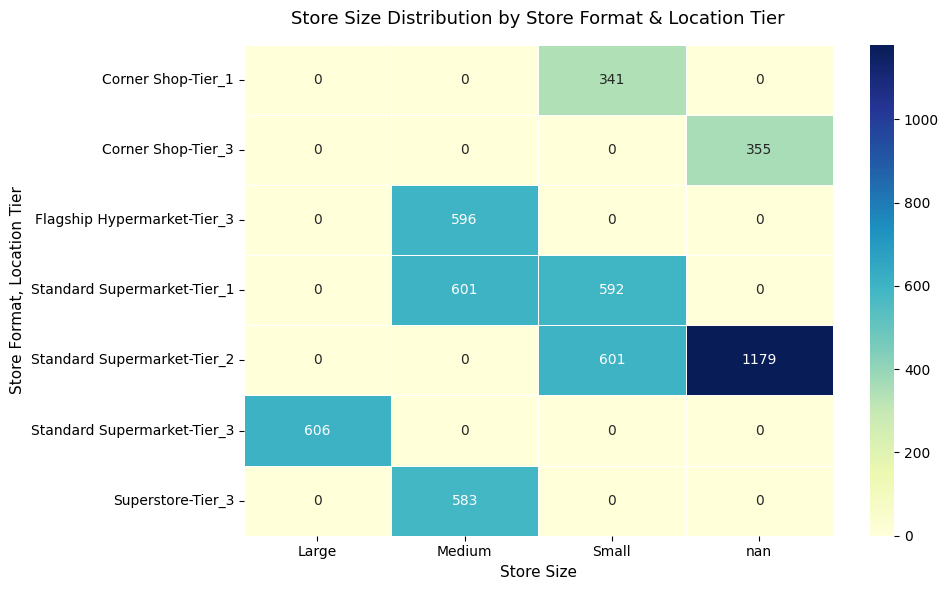

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data (normalize across rows to show percentages)
cross_tab = (
    train_df.groupby(["store_format", "store_location_tier"])["store_size"]
    .value_counts(dropna=False)
    .unstack(fill_value=0)
)

# Rename NaN column for clear labeling
cross_tab = cross_tab.rename(columns={float("nan"): "Missing (NaN)"})

# 2. Plotting an Annotated Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=True,
    linewidths=0.5,
)
plt.title(
    "Store Size Distribution by Store Format & Location Tier",
    fontsize=13,
    pad=15,
)
plt.xlabel("Store Size", fontsize=11)
plt.ylabel("Store Format, Location Tier", fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------------------------
# INSIGHT & DECISION: Missing Values in `store_size`
# -------------------------------------------------------------------------
# Observation:
# - `store_size` has 1,534 missing entries and shares strong domain overlap
#   with `store_format` and `store_location_tier`.
# - Missingness is concentrated systematically across specific store codes
#   rather than occurring at random row-level intervals.
#
# Evaluation (To Drop vs. To Keep):
# - While collinear with `store_format`, dropping `store_size` discards
#   granular scale signals that tree-based algorithms (LightGBM/XGBoost/CatBoost)
#   use effectively for split decisions and interaction features.
# - Unlike linear models, gradient-boosted trees are robust to multicollinearity
#   and can derive utility from structural missingness.
#
# Handling Plan:
# 1. Inspect the cross-tabulation of `(store_format, store_location_tier)` against `store_size`.
# 2. If a specific format-tier combination unambiguously determines size (e.g., Grocery Stores
#    consistently mapping to 'Small'), impute using that group mode.
# 3. For any ambiguous cases, retain the signal by encoding the nulls explicitly
#    as a distinct category: `'Missing'`.
# -------------------------------------------------------------------------

ways to fill missing values

ways to encode categorical variables